In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import h3
import xgboost as xgb
from tqdm import tqdm
import seaborn as sns
import re
import datetime
import os
import random
import h3

In [139]:
h3_l7_df = pd.read_csv('../../data/processed/h3_l7_df_new.csv')
h3_l7_df.drop(columns=['commercial;yes'], inplace=True)
h3_l7_df

,id,place_of_worship,grave_yard,school,post_office,childcare,university,courthouse,fire_station,library,...,warehouse,sports_centre,detached,boathouse,barn,riding_hall,construction,ship,ruins,ohca
0,872af0424ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,872af0425ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,872af0426ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
3,872af0500ffffff,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,872af0501ffffff,0,0,1,0,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,872af6373ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
173,872af6375ffffff,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,20
174,872af6acaffffff,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
175,872af6ad9ffffff,2,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,2


In [140]:
def analyze_df_stats(df , feature):
    """
    計算 DataFrame 中 'ohca' 欄位與 'total_building' 欄位的
    平均數、眾數和標準差，並印出結果。

    'total_building' 是透過加總 'ohca' 和 'id' 以外的所有欄位計算得出的。
    
    參數:
    df (pd.DataFrame): 必須包含 'ohca', 'id' 
                       以及其他您想加總的數值型態欄位。
    """
    
    # 建立一個副本，避免修改到傳入的原始 DataFrame (這是良好的做法)
    df_copy = df.copy()

    # --- 1. 建立 'total_building' 欄位 ---
    try:
        # 移除 'ohca' 和 'id'，然後沿著 "列" (axis=1) 加總
        total_building = df_copy.drop(['ohca', 'id'], axis=1).sum(axis=1)
        
        # 將計算結果存回 df_copy 的新欄位
        df_copy['total_building'] = total_building
        
    except KeyError as e:
        print(f"錯誤：輸入的 DataFrame 中缺少必要欄位 {e}。")
        return
    except TypeError as e:
        print(f"錯誤：有非數值欄位無法加總 (排除 'ohca', 'id' 後)。 {e}")
        return

    sum = df_copy[feature].sum()
    mean = df_copy[feature].mean()
    mode = df_copy[feature].mode()[0]
    std = df_copy[feature].std()
    median = df_copy[feature].median() 

    print(f"{feature} 總數 (Sum): {sum}")
    print(f"{feature} 平均數 (Mean): {mean}")
    print(f"{feature} 眾數 (Mode): {mode}")
    print(f"{feature} 標準差 (Standard Deviation): {std}")
    print(f"{feature} 中位數 (Median): {median} \n") 

    


In [141]:
analyze_df_stats(h3_l7_df, 'ohca')
analyze_df_stats(h3_l7_df, 'total_building')


ohca 總數 (Sum): 1983
ohca 平均數 (Mean): 11.203389830508474
ohca 眾數 (Mode): 0
ohca 標準差 (Standard Deviation): 16.996102154428222
ohca 中位數 (Median): 2.0 

total_building 總數 (Sum): 138085
total_building 平均數 (Mean): 780.1412429378531
total_building 眾數 (Mode): 1
total_building 標準差 (Standard Deviation): 951.3442268136325
total_building 中位數 (Median): 254.0 



In [142]:

df_copy = h3_l7_df.drop(['ohca', 'id'], axis=1)
distinct_nonzero_counts = df_copy.apply(lambda row: row[row != 0].nunique(), axis=1)

print("========= 每列不同非 0 值的數量 (distinct_nonzero_counts) ==========")
print(distinct_nonzero_counts)
print("=" * (40 + 38))
print("\n")

# 3. 計算並印出平均值
mean_value = distinct_nonzero_counts.mean()
print("========= 平均值 (Mean) ==========")
print(mean_value)
print("=" * (40 + 2))
print("\n")

# --- 計算並印出標準差 ---
std_deviation = distinct_nonzero_counts.std()
print("========= 標準差 (Standard Deviation) ==========")
print(std_deviation)
print("=" * (40 + 17))
print("\n")


median_values = distinct_nonzero_counts.median()
print("========= 中位數 (Median) ==========")
print(median_values)
print("=" * (40 + 2))
print("\n")

    

========= 每列不同非 0 值的數量 (distinct_nonzero_counts) ==========
0       2
1       0
2       0
3       7
4       6
       ..
172     5
173    10
174     2
175     5
176     3
Length: 177, dtype: int64


========= 平均值 (Mean) ==========
7.073446327683616


========= 標準差 (Standard Deviation) ==========
3.856845447427412


========= 中位數 (Median) ==========
7.0




# train & test

In [143]:
train_index=[]
test_index=[]
for i in range(0,h3_l7_df.shape[0]):
    geo_location = h3.h3_to_geo(h3_l7_df.iloc[i]['id'])

    if (geo_location[1]) > (-76.05): #把經度大於-76.05的 當train (東邊是train)
        train_index.append(i)
    else:
        test_index.append(i)

# 分割訓練集和測試集
train_h3_l7_df = h3_l7_df.iloc[train_index]
test_h3_l7_df = h3_l7_df.iloc[test_index]

# 將 h3_l7_df 資料框中的 'id' 列移除，僅保留數據進行正規化
h3_spatial_data = h3_l7_df.drop('id', axis=1)


# # # 對數據進行正規化：將每個數據列的最小值調整為 0，最大值調整為 1
normalized_spatial_data = (h3_spatial_data - h3_spatial_data.min()) / (h3_spatial_data.max() - h3_spatial_data.min())

#設定OHCA正規化反函數 方便把預測結果返回原本scale
ohca_reguli_inverse = (h3_l7_df.ohca.max()-h3_l7_df.ohca.min()) + h3_l7_df.ohca.min()

# 將 DataFrame 轉換為 numpy array，並設定數據類型為 np.float64
spatial_data = np.array(normalized_spatial_data).astype(np.float64)


train_spatial_data = spatial_data[train_index]
test_spatial_data = spatial_data[test_index]

# 分离特征和标签
X = spatial_data[:, :-1]  # 特征
Y = spatial_data[:, -1]   # 标签（OHCA）

X_train_reguli = train_spatial_data[:, :-1] 
y_train_reguli = train_spatial_data[:, -1] 
X_test_reguli = test_spatial_data[:, :-1] 
y_test_reguli = test_spatial_data[:, -1] 

In [144]:
def analyze_df_stats_sum(df , feature):
    """
    計算 DataFrame 中 'ohca' 欄位與 'total_building' 欄位的
    平均數、眾數和標準差，並印出結果。

    'total_building' 是透過加總 'ohca' 和 'id' 以外的所有欄位計算得出的。
    
    參數:
    df (pd.DataFrame): 必須包含 'ohca', 'id' 
                       以及其他您想加總的數值型態欄位。
    """
    
    # 建立一個副本，避免修改到傳入的原始 DataFrame (這是良好的做法)
    df_copy = df.copy()

    # --- 1. 建立 'total_building' 欄位 ---
    try:
        # 移除 'ohca' 和 'id'，然後沿著 "列" (axis=1) 加總
        total_building = df_copy.drop(['ohca', 'id'], axis=1).sum(axis=1)
        
        # 將計算結果存回 df_copy 的新欄位
        df_copy['total_building'] = total_building
        
    except KeyError as e:
        print(f"錯誤：輸入的 DataFrame 中缺少必要欄位 {e}。")
        return
    except TypeError as e:
        print(f"錯誤：有非數值欄位無法加總 (排除 'ohca', 'id' 後)。 {e}")
        return

    # --- 2. 計算 'ohca' 欄位的統計數據 ---
    sum = df_copy[feature].sum()



    # --- 4. 分別印出兩組結果 ---
    print(f"{feature} 加總: {sum}")


In [145]:
test_h3_l7_df

,id,place_of_worship,grave_yard,school,post_office,childcare,university,courthouse,fire_station,library,...,warehouse,sports_centre,detached,boathouse,barn,riding_hall,construction,ship,ruins,ohca
0,872af0424ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,872af0425ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,872af0426ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
5,872af0502ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
6,872af0503ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,872af6370ffffff,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,25
170,872af6371ffffff,2,0,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
171,872af6372ffffff,3,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,20
172,872af6373ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


In [146]:
train_h3_l7_df

,id,place_of_worship,grave_yard,school,post_office,childcare,university,courthouse,fire_station,library,...,warehouse,sports_centre,detached,boathouse,barn,riding_hall,construction,ship,ruins,ohca
3,872af0500ffffff,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,872af0501ffffff,0,0,1,0,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
7,872af0504ffffff,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
8,872af0505ffffff,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
9,872af0509ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,872af636dffffff,4,0,3,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,56
168,872af636effffff,2,0,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,26
174,872af6acaffffff,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
175,872af6ad9ffffff,2,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,2


In [147]:
analyze_df_stats_sum(train_h3_l7_df, 'ohca')
analyze_df_stats_sum(train_h3_l7_df, 'total_building')

ohca 加總: 479
total_building 加總: 38361


In [148]:
analyze_df_stats_sum(test_h3_l7_df, 'ohca')
analyze_df_stats_sum(test_h3_l7_df, 'total_building')

ohca 加總: 1504
total_building 加總: 99724


In [149]:
analyze_df_stats_sum(h3_l7_df, 'ohca')
analyze_df_stats_sum(h3_l7_df, 'total_building')

ohca 加總: 1983
total_building 加總: 138085


In [150]:
features_to_drop = ['id'] 
train_feature_means = train_h3_l7_df.drop(columns=features_to_drop).mean(axis=0)
train_feature_means

place_of_worship    0.759036
grave_yard          0.036145
school              0.638554
post_office         0.060241
childcare           0.072289
                      ...   
riding_hall         0.012048
construction        0.024096
ship                0.012048
ruins               0.012048
ohca                5.771084
Length: 115, dtype: float64

In [151]:
test_feature_means = test_h3_l7_df.drop(columns=features_to_drop).mean(axis=0)
test_feature_means


place_of_worship     1.670213
grave_yard           0.106383
school               1.648936
post_office          0.085106
childcare            0.138298
                      ...    
riding_hall          0.000000
construction         0.010638
ship                 0.000000
ruins                0.000000
ohca                16.000000
Length: 115, dtype: float64

In [152]:
test_feature_means['house']

772.1595744680851

                  Train_Mean  Test_Mean
place_of_worship    0.759036   1.670213
grave_yard          0.036145   0.106383
school              0.638554   1.648936
post_office         0.060241   0.085106
childcare           0.072289   0.138298
...                      ...        ...
riding_hall         0.012048   0.000000
construction        0.024096   0.010638
ship                0.012048   0.000000
ruins               0.012048   0.000000
ohca                5.771084  16.000000

[115 rows x 2 columns]
----------------------------------------


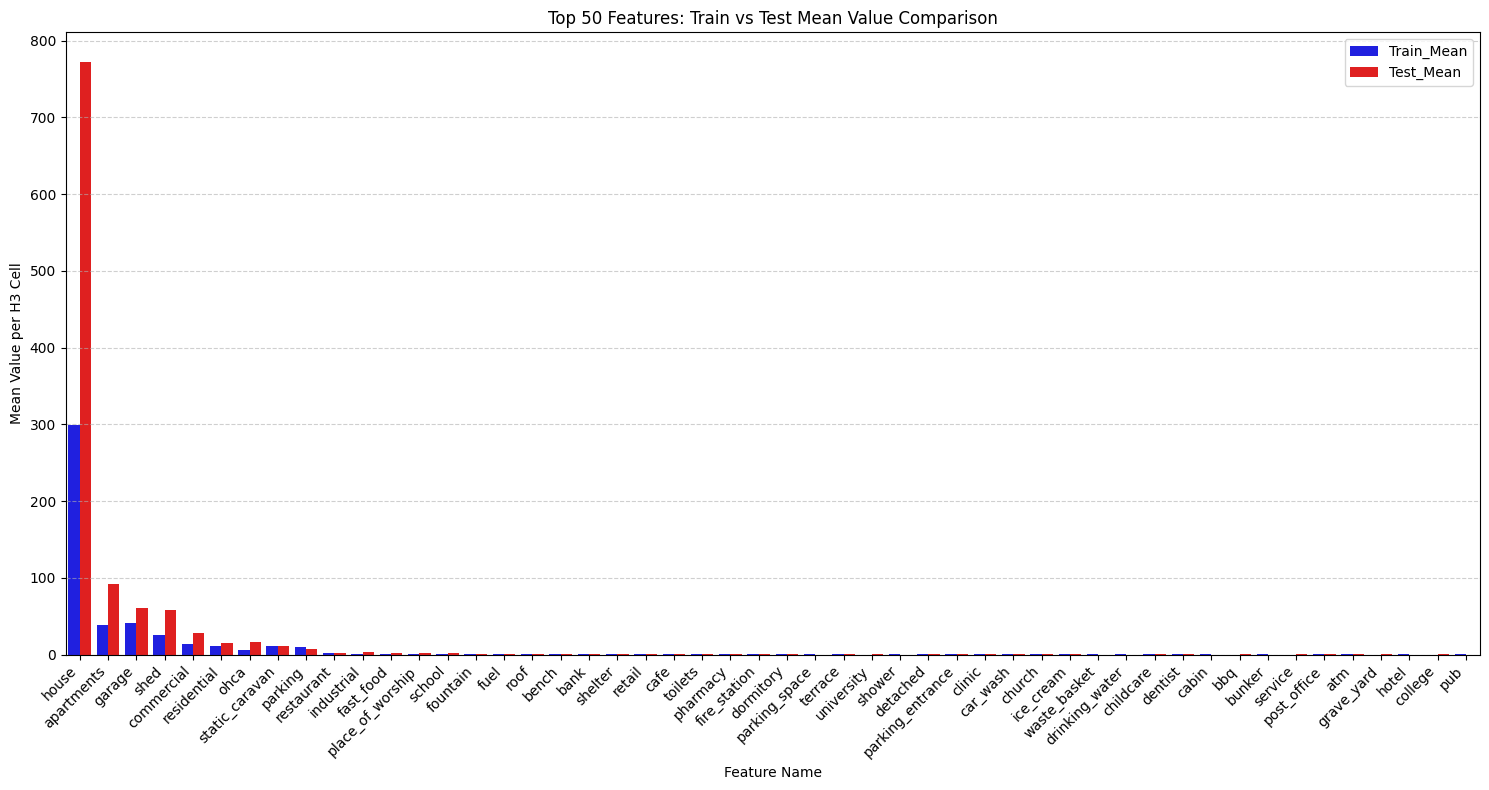

In [153]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


compare_df = pd.DataFrame({
    'Train_Mean': train_feature_means,
    'Test_Mean': test_feature_means
}).fillna(0) # 如果某個 feature 在其中一個 set 完全不存在，用 0 填充

print(compare_df)
print("-" * 40)

top_n = 50
top_features = compare_df.sum(axis=1).nlargest(top_n).index
top_features_df = compare_df.loc[top_features]

# 我們需要將 DataFrame "融化" (melt)，才能用 seaborn 繪製分組長條圖
top_features_df_melted = top_features_df.reset_index().melt(
    id_vars='index', 
    var_name='Dataset', 
    value_name='Mean_Value'
)
top_features_df_melted = top_features_df_melted.rename(columns={'index': 'Feature'})

# 繪圖
plt.figure(figsize=(15, 8))
sns.barplot(
    data=top_features_df_melted,
    x='Feature',
    y='Mean_Value',
    hue='Dataset', # 關鍵：用 'Dataset' (Train/Test) 來區分顏色
palette={'Train_Mean': 'blue', 'Test_Mean': 'red'}
)
plt.title(f'Top {top_n} Features: Train vs Test Mean Value Comparison')
plt.xlabel('Feature Name')
plt.ylabel('Mean Value per H3 Cell')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6, axis='y')
plt.tight_layout()
plt.show()

In [154]:
import pandas as pd
from scipy.stats import wilcoxon
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import jensenshannon


# 確保我們比較的是相同的特徵，並且移除兩者皆為 0 的特徵 (它們對比較沒有貢獻)
compare_df_clean = compare_df.loc[~( (compare_df['Train_Mean'] == 0) & (compare_df['Test_Mean'] == 0) )]

# 提取兩個 Series (向量)
train_vector = compare_df_clean['Train_Mean']
test_vector = compare_df_clean['Test_Mean']


### 方法 1: Wilcoxon Signed-Rank Test (統計檢定)
# 
# 注意：如果兩個 Series 完全相同，wilcoxon 會報錯。
# 我們要處理 Train 和 Test 數值完全相等的情況 (difference = 0)
# 'zero_method='pratt'' 可以處理有 0 差異的情況
statistic, p_value = wilcoxon(train_vector, test_vector, zero_method='pratt')

print("--- 1. Wilcoxon 檢定 (統計顯著性) ---")
print(f"P-value: {p_value:.6f}")
if p_value <= 0.05:
    print(f"結論：P-value ({p_value:.6f}) <= 0.05，兩個分佈有【統計上的顯著差異】。")
else:
    print(f"結論：P-value ({p_value:.6f}) > 0.05，兩個分佈在統計上【沒有顯著差異】。")
print("-" * 40)


### 方法 2A: 餘弦相似度 (Cosine Similarity)
# 需要將 Series 轉換為 [[...]] 2D 陣列
cos_sim = cosine_similarity(
    train_vector.values.reshape(1, -1),
    test_vector.values.reshape(1, -1)
)

print("--- 2A. 餘弦相似度 (比例相似性) ---")
print(f"Cosine Similarity Score: {cos_sim[0][0]:.6f}")
print(" (分數越接近 1，代表特徵的「相對比例」越相似，即使絕對數值不同)")
print("-" * 40)


### 方法 2B: 詹森-香農散度 (Jensen-Shannon Divergence, JSD)
# 
# 步驟 1: 將向量轉換為機率分佈 (使其總和為 1)
# 我們必須先處理負數或極小數，確保總和不為 0
train_prob = train_vector / train_vector.sum()
test_prob = test_vector / test_vector.sum()

# 步驟 2: 計算 JSD
# (我們需要處理其中一個機率為 0 的情況，將 NaN 替換為 0)
train_prob = train_prob.fillna(0)
test_prob = test_prob.fillna(0)

jsd_score = jensenshannon(train_prob, test_prob)

print("--- 2B. 詹森-香農散度 (JSD) (分佈距離) ---")
print(f"JSD Score: {jsd_score:.6f}")
print(" (分數越接近 0，代表兩個分佈越【完全相同】)")
print("-" * 40)

--- 1. Wilcoxon 檢定 (統計顯著性) ---
P-value: 0.005567
結論：P-value (0.005567) <= 0.05，兩個分佈有【統計上的顯著差異】。
----------------------------------------
--- 2A. 餘弦相似度 (比例相似性) ---
Cosine Similarity Score: 0.997381
 (分數越接近 1，代表特徵的「相對比例」越相似，即使絕對數值不同)
----------------------------------------
--- 2B. 詹森-香農散度 (JSD) (分佈距離) ---
JSD Score: 0.100400
 (分數越接近 0，代表兩個分佈越【完全相同】)
----------------------------------------
